In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

N = 300
np.random.seed(42) 

data = {
    'engine': np.random.choice(['Tesseract', 'EasyOCR', 'PaddleOCR'], N),
    'image_name': [f'image_{i}.png' for i in range(N)],
    'isik_durumu': np.random.choice(['iyi', 'orta', 'kotu'], N, p=[0.5, 0.3, 0.2]),
   
    'confidence_score': (np.random.rand(N) * 0.4) + 0.5,
    'processing_time_ms': (np.random.rand(N) * 100) + 50 
}

df = pd.DataFrame(data)


df.loc[df['engine'] == 'EasyOCR', 'confidence_score'] += 0.1

df.loc[df['engine'] == 'Tesseract', 'processing_time_ms'] -= 20

df.loc[df['isik_durumu'] == 'kotu', 'confidence_score'] -= 0.3

df['confidence_score'] = np.clip(df['confidence_score'], 0, 1.0)

df.to_csv('ocr_results.csv', index=False)
print("ocr_results.csv oluşturuldu!")

ocr_results.csv oluşturuldu!


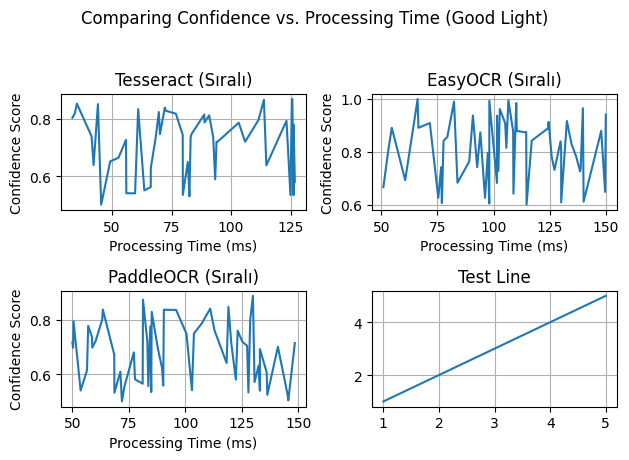

In [95]:
data_p1=pd.read_csv("C:\\Users\\user\\ocr_results.csv")
data_p1.head(100)
data_p1_Tesseract=data_p1[data_p1['engine'] == 'Tesseract']
data_p1_EasyOCR=data_p1[data_p1['engine'] == 'EasyOCR']
data_p1_PaddleOCR=data_p1[data_p1['engine'] == 'PaddleOCR']

data_p1_Tesseract_iyi = data_p1_Tesseract[data_p1_Tesseract['isik_durumu'] == 'iyi']
data_p1_EasyOCR_iyi = data_p1_EasyOCR[data_p1_EasyOCR['isik_durumu'] == 'iyi']
data_p1_PaddleOCR_iyi = data_p1_PaddleOCR[data_p1_PaddleOCR['isik_durumu'] == 'iyi']



data_p1_Tesseract_iyi = data_p1_Tesseract[data_p1_Tesseract['isik_durumu'] == 'iyi']
data_p1_EasyOCR_iyi = data_p1_EasyOCR[data_p1_EasyOCR['isik_durumu'] == 'iyi']
data_p1_PaddleOCR_iyi = data_p1_PaddleOCR[data_p1_PaddleOCR['isik_durumu'] == 'iyi']



tesseract_sirali = data_p1_Tesseract_iyi.sort_values(by="processing_time_ms")
easyocr_sirali = data_p1_EasyOCR_iyi.sort_values(by="processing_time_ms")
paddleocr_sirali = data_p1_PaddleOCR_iyi.sort_values(by="processing_time_ms")



plt.suptitle("Comparing Confidence vs. Processing Time (Good Light)")


plt.subplot(2, 2, 1)

plt.plot(tesseract_sirali["processing_time_ms"], tesseract_sirali["confidence_score"])
plt.title("Tesseract (Sıralı)")
plt.grid(True)
plt.xlabel("Processing Time (ms)")
plt.ylabel("Confidence Score")

plt.subplot(2, 2, 2)
plt.plot(easyocr_sirali["processing_time_ms"], easyocr_sirali["confidence_score"])
plt.title("EasyOCR (Sıralı)")
plt.grid(True)
plt.xlabel("Processing Time (ms)")
plt.ylabel("Confidence Score")

plt.subplot(2, 2, 3)
plt.plot(paddleocr_sirali["processing_time_ms"], paddleocr_sirali["confidence_score"])
plt.title("PaddleOCR (Sıralı)")
plt.grid(True)
plt.xlabel("Processing Time (ms)")
plt.ylabel("Confidence Score")


x = [1, 5]
y = [1, 5]
plt.subplot(2, 2, 4)
plt.plot(x, y)
plt.title("Test Line")
plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
